In [27]:
# Ilja Rasin (original colaborator)
# Senior AI and Cognitive Consultant
# Data & Optimization Sciences, Inc.
# Dr. Michael P. Haydock
# IBM Fellow Emeritus
# Data & Optimization Sciences, Inc.
# Initial coding: 5/1/2024
# Objective: Stock Price Forecast using LTSM Recurrent Neural Network structure
#
# Property of the IBM Corporation - All Rights Reserved - Proper citations apply
# !activate tensorflow
# Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import utils

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import numpy as np

# Suppress deprecation warnings
from tensorflow.python.util import deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False
print("Using TensorFlow backend:", tf.__version__)

Using TensorFlow backend: 2.18.0


In [28]:
# Recurrent Neural Network
# Part 1 - Data Preprocessing

# Importing the training set - 5 years of daily opening data
# 1258 Rows
dataset_train = pd.read_csv('NVDA - Training.csv')
# Pick up the opening price
training_set = dataset_train.iloc[:, 1:2].values
# Print out the first few rows of data
dataset_train.head()

# Feature Scaling
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)

# Creating a data structure with 60 timesteps and 1 output
X_train = []
y_train = []
for i in range(60, 1258):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshaping - Building the arrays
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [29]:
# Part 2 - Building the RNN

# Initialising the RNN - Sequential classification and pattern recognition
regressor = Sequential()

# Adding the first LSTM layer and some Dropout regularisation
# 50 = the dimensionality of the output space
regressor.add(LSTM(units = 50, return_sequences = True, input_shape = (X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# Adding a second LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a third LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a fourth LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))

# Adding the output layer
regressor.add(Dense(units = 1))

# Compiling the RNN - Gradient decent optimizer 
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

# Fitting the RNN to the Training set
regressor.fit(X_train, y_train, epochs = 100, batch_size = 32)

Epoch 1/100


/Users/alexanderdagher/Documents/new project/myenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0297
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0032
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0036
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0032
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0022
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0028
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0033
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0023
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0021
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0020
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0032
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0023
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0018
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0019
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0024
E

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


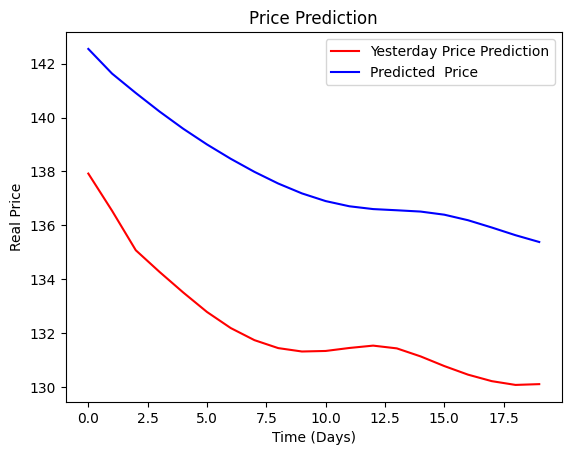

In [30]:
# Part 3 - Making the predictions and visualising the results
# Predict the daily VIX prices

# Getting the stock price prediction using the machine learning 100 epoch model output (20 values)
dataset_test = pd.read_csv('NVDA - Test.csv')
DATE = dataset_test.iloc[:, 0:1].values  

real_stock_price = dataset_test.iloc[:, 1:2].values
# print (real_stock_price)
# Getting the predicted stock price using the machine learning 100 epoch model
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis = 0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)
X_test = []
for i in range(60, 80):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
# print (predicted_VIX_price)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)
# print (predicted_VIX_price)
# Visualising the results
plt.plot(real_stock_price, color = 'red', label = 'Yesterday Price Prediction')
plt.plot(predicted_stock_price, color = 'blue', label = 'Predicted  Price')
plt.title('Price Prediction')
plt.xlabel('Time (Days)')
plt.ylabel('Real Price')
plt.legend()
plt.show()


# Ensure all arrays have the same length
min_length = min(len(DATE), len(real_stock_price), len(predicted_stock_price))
DATE = DATE[:min_length]
real_stock_price = real_stock_price[:min_length]
predicted_stock_price = predicted_stock_price[:min_length]

# Combine arrays and save to CSV
output_test = np.column_stack((DATE, real_stock_price, predicted_stock_price))
np.savetxt("Fitted Data Output.csv", output_test, delimiter=',', fmt='%s', header="DATE, Yesterday Price, Predicted Price")